# ***Part I: BERT_ordinal Movie script classification***

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Set your base path
base_path = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/English_bal"

# Update the parse_filename function (ONLY THIS FUNCTION NEEDS TO CHANGE)
def parse_filename(filename):
    """Robust filename parser that handles titles with 'The' and other edge cases"""
    basename = os.path.splitext(filename)[0]
    parts = basename.split('_')

    # Normalize ratings
    rating_map = {
        'PG13': 'PG-13',
        'PG-13': 'PG-13',
        'NC17': 'NC-17',
        'NC-17': 'NC-17'
    }
    rating = parts[0].upper()
    rating = rating_map.get(rating, rating)

    # Improved year extraction using regex to find 4-digit numbers
    year = None
    year_pattern = re.compile(r'^(19|20)\d{2}$')  # Only 1900-2099

    # Check from end backwards first
    for part in reversed(parts):
        if year_pattern.match(part):
            year = part
            break

    # If not found, check any position
    if not year:
        for part in parts:
            if year_pattern.match(part):
                year = part
                break

    if not year:
        raise ValueError(f"Year not found in filename: {filename}")

    # Get all parts between rating and year
    year_idx = parts.index(year)
    title_parts = parts[1:year_idx]

    # Special handling for titles containing "The"
    if len(title_parts) > 1 and title_parts[-1] == 'The':
        # Move "The" to beginning (e.g., ["Matrix", "The"] -> ["The", "Matrix"])
        title_parts = [title_parts[-1]] + title_parts[:-1]

    title = ' '.join(title_parts)  # Use space instead of underscore for readability

    return {
        'filename': filename,
        'rating': rating,
        'title': title,  # Now with spaces instead of underscores
        'year': int(year),
        'filepath': os.path.join(base_path, filename)
    }

# Create metadata dataframe
metadata = []
for filename in os.listdir(base_path):
    if filename.endswith('.txt'):
        try:
            metadata.append(parse_filename(filename))
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")

df = pd.DataFrame(metadata)

Mounted at /content/drive


In [2]:
# 2. Data Analysis and Visualization
print("\nRating Distribution:")
print(df['rating'].value_counts())



Rating Distribution:
rating
R        50
PG       50
G        50
PG-13    50
NC-17    50
Name: count, dtype: int64


In [3]:
# 1. Metadata Extraction

# Set your base path
base_path = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/English_bal"

# Function to parse filename
def parse_filename(filename):
    """Parses filename to extract rating, title, and year."""
    basename = os.path.splitext(filename)[0]
    parts = basename.split('_')

    # Assuming the format is Rating_Title_Year.txt
    rating = parts[0]
    year = int(parts[-1])
    title = '_'.join(parts[1:-1])

    return {
        'filename': filename,
        'rating': rating,
        'title': title,
        'year': year,
        'filepath': os.path.join(base_path, filename)
    }

# Create metadata dataframe
metadata = []
for filename in os.listdir(base_path):
    if filename.endswith('.txt'):
        metadata.append(parse_filename(filename))

df = pd.DataFrame(metadata)

# Display the first few rows of the dataframe
display(df.head())

,filename,rating,title,year,filepath
0,R_Smashed_2012.txt,R,Smashed,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
1,R_Pariah_2011.txt,R,Pariah,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
2,R_My_Week_with_Marilyn_2011.txt,R,My_Week_with_Marilyn,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
3,R_Margaret_2011.txt,R,Margaret,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...
4,PG_Life_of_Pi_2012.txt,PG,Life_of_Pi,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...


In [4]:
# 2. Text Preprocessing

def preprocess_text(filepath):
    """Loads and preprocesses text from a file."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read()

    # Basic cleaning: lowercasing, remove punctuation and special characters, normalize whitespace
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Keep letters, numbers, and whitespace
    text = re.sub(r'\s+', ' ', text).strip() # Normalize whitespace

    return text

# Load and preprocess text for each file and add to the dataframe
df['clean_script'] = df['filepath'].apply(preprocess_text)

# Display the first few entries with the new 'clean_script' column
display(df.head())

,filename,rating,title,year,filepath,clean_script
0,R_Smashed_2012.txt,R,Smashed,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,smashed written by james ponsoldt susan burke ...
1,R_Pariah_2011.txt,R,Pariah,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,pariah written by dee rees super wherever the ...
2,R_My_Week_with_Marilyn_2011.txt,R,My_Week_with_Marilyn,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,my week with marilyn written by adrian hodges ...
3,R_Margaret_2011.txt,R,Margaret,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,margaret written by kenneth lonergan november ...
4,PG_Life_of_Pi_2012.txt,PG,Life_of_Pi,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,life of pi written by david magee based on the...


In [5]:
# 3. Script Chunking and Class Imbalance Handling

# Define a maximum chunk size (e.g., based on BERT's limit minus some buffer)
MAX_CHUNK_SIZE = 512 # Adjust based on the specific BERT model used and desired overlap

def chunk_script(script, chunk_size=MAX_CHUNK_SIZE, overlap=50):
    """Splits a script into overlapping chunks."""
    words = script.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = words[i:i + chunk_size]
        chunks.append(" ".join(chunk))
    return chunks

# Apply chunking to the 'clean_script' column
df['script_chunks'] = df['clean_script'].apply(lambda x: chunk_script(x, chunk_size=MAX_CHUNK_SIZE))

# Handle class imbalance by calculating class weights
# This is a common approach for imbalanced datasets in classification
from sklearn.utils.class_weight import compute_class_weight

# Get unique classes and their counts
classes = np.unique(df['rating'])
class_weights = compute_class_weight('balanced', classes=classes, y=df['rating'])
class_weight_dict = dict(zip(classes, class_weights))

print("\nClass Weights:")
print(class_weight_dict)

# Display the first few entries with the new 'script_chunks' column
display(df.head())


Class Weights:
{'G': np.float64(1.0), 'NC-17': np.float64(1.0), 'PG': np.float64(1.0), 'PG-13': np.float64(1.0), 'R': np.float64(1.0)}


,filename,rating,title,year,filepath,clean_script,script_chunks
0,R_Smashed_2012.txt,R,Smashed,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,smashed written by james ponsoldt susan burke ...,[smashed written by james ponsoldt susan burke...
1,R_Pariah_2011.txt,R,Pariah,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,pariah written by dee rees super wherever the ...,[pariah written by dee rees super wherever the...
2,R_My_Week_with_Marilyn_2011.txt,R,My_Week_with_Marilyn,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,my week with marilyn written by adrian hodges ...,[my week with marilyn written by adrian hodges...
3,R_Margaret_2011.txt,R,Margaret,2011,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,margaret written by kenneth lonergan november ...,[margaret written by kenneth lonergan november...
4,PG_Life_of_Pi_2012.txt,PG,Life_of_Pi,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,life of pi written by david magee based on the...,[life of pi written by david magee based on th...


In [6]:
import torch
import torch.nn as nn
from transformers import BertModel

# Define a custom loss function for ordinal regression
# This loss function is based on the cumulative probabilities
class OrdinalRegressionLoss(nn.Module):
    def __init__(self, num_labels, class_weights=None):
        super(OrdinalRegressionLoss, self).__init__()
        self.num_labels = num_labels
        # Class weights will be passed during Trainer initialization if needed,
        # so we don't initialize them here with a specific dict like class_weight_dict
        self.class_weights = class_weights

    def forward(self, cumulative_logits, labels):
        # cumulative_logits shape: (batch_size, num_labels - 1)
        # labels shape: (batch_size,)

        # Convert labels to cumulative binary targets
        # For a label 'y', the target is [1, 1, ..., 1, 0, 0, ..., 0] where there are 'y' ones.
        batch_size = labels.size(0)
        cumulative_targets = torch.zeros(batch_size, self.num_labels - 1, dtype=torch.float32).to(cumulative_logits.device)
        for i in range(batch_size):
            # Ensure labels[i] is within the valid range for indexing cumulative_targets
            if labels[i] > 0:
                cumulative_targets[i, :labels[i]] = 1.0

        # Apply sigmoid to get cumulative probabilities
        cumulative_probs = torch.sigmoid(cumulative_logits)

        # Calculate Binary Cross-Entropy loss for each threshold
        # We use the class weights to handle imbalance if provided
        if self.class_weights is not None:
            # Expand weights to match the shape of cumulative_targets
            # We assume class_weights are provided as a tensor with shape (num_labels,)
            # and we need weights for the num_labels - 1 thresholds.
            # A simple approach is to use the weights of the two classes involved in each threshold.
            # For threshold i, the classes are i and i+1. We can use the weight of class i+1 as the weight for the positive class (1)
            # and the weight of class i as the weight for the negative class (0).
            # This requires careful consideration of how weights are applied in BCEWithLogitsLoss or manual BCE.
            # For simplicity with BCE, we can use a single weight per threshold. A common approach is to use the weight of the positive class.
            # Let's use the weight of the class *after* the threshold as the weight for the positive (1) target.
            # For threshold 0 (G vs PG and above), the positive target corresponds to PG and above (class 1 and up). Use weight of class 1.
            # For threshold 1 (PG vs PG-13 and above), the positive target corresponds to PG-13 and above (class 2 and up). Use weight of class 2.
            # ...
            # For threshold num_labels-2 (R vs NC-17), the positive target corresponds to NC-17 (class num_labels-1). Use weight of class num_labels-1.

            # This requires the class_weights tensor to be ordered according to the ordinal mapping (G, PG, PG-13, R, NC-17)
            # Let's re-initialize the loss function later with the correctly ordered weights tensor.
            # For now, we'll initialize without weights and add them when creating the Trainer.
            # The Trainer can handle class weights directly if the model's forward returns loss.

            # Let's remove the class_weights initialization from __init__ and handle it in the training loop or Trainer.
            # For now, calculate BCE without weights in the loss function itself.
             loss = nn.functional.binary_cross_entropy_with_logits(cumulative_logits, cumulative_targets, reduction='mean')

        else:
             loss = nn.functional.binary_cross_entropy_with_logits(cumulative_logits, cumulative_targets, reduction='mean')


        return loss

class HierarchicalBERTOrdinal(nn.Module):
    def __init__(self, num_labels, bert_model_name='bert-base-uncased'):
        super(HierarchicalBERTOrdinal, self).__init__()
        self.num_labels = num_labels

        # Chunk Encoder (BERT)
        self.chunk_encoder = BertModel.from_pretrained(bert_model_name)

        # Document Aggregator (Another BERT)
        # We'll use the [CLS] token embedding from the chunk encoder as input to the aggregator
        self.aggregator = BertModel.from_pretrained(bert_model_name)

        # Ordinal Regression Layer
        # The aggregator outputs a representation for the entire document.
        # We'll use a linear layer to predict the cumulative probabilities for ordinal regression.
        # For K classes, we need K-1 outputs for cumulative probabilities.
        self.ordinal_layer = nn.Linear(self.aggregator.config.hidden_size, num_labels - 1)

        # Define the ordinal regression loss function within the model
        self.loss_function = OrdinalRegressionLoss(num_labels=num_labels) # Initialize here without weights yet

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # input_ids, attention_mask, token_type_ids should be lists of tensors, one for each chunk

        chunk_embeddings = []
        for i in range(len(input_ids)):
            chunk_input_ids = input_ids[i]
            chunk_attention_mask = attention_mask[i]
            chunk_token_type_ids = token_type_ids[i] if token_type_ids is not None else None

            # Ensure tensors have a batch dimension
            chunk_input_ids = chunk_input_ids.unsqueeze(0)
            chunk_attention_mask = chunk_attention_mask.unsqueeze(0)
            if chunk_token_type_ids is not None:
                chunk_token_type_ids = chunk_token_type_ids.unsqueeze(0)

            # Get embeddings from chunk encoder
            outputs = self.chunk_encoder(input_ids=chunk_input_ids,
                                         attention_mask=chunk_attention_mask,
                                         token_type_ids=chunk_token_type_ids)

            # Use the [CLS] token embedding as the chunk representation
            chunk_embedding = outputs.last_hidden_state[:, 0, :] # (1, hidden_size)
            chunk_embeddings.append(chunk_embedding)

        # Stack chunk embeddings to form a sequence for the aggregator
        # The aggregator expects a batch of sequences. Here, each sequence is a document
        # composed of chunk embeddings. We process one document (script) at a time.
        document_representation = torch.cat(chunk_embeddings, dim=0).unsqueeze(0) # (1, num_chunks, hidden_size)

        # Pass the document representation through the aggregator
        aggregator_outputs = self.aggregator(inputs_embeds=document_representation)

        # Use the [CLS] token embedding from the aggregator as the document representation
        document_embedding = aggregator_outputs.last_hidden_state[:, 0, :] # (1, hidden_size)

        # Pass the document embedding through the ordinal regression layer
        # The output are the logits for the cumulative probabilities
        cumulative_logits = self.ordinal_layer(document_embedding) # (1, num_labels - 1)

        loss = None
        if labels is not None:
             # Use the loss function defined within the model
            loss = self.loss_function(cumulative_logits, labels)

        # Return loss and logits (logits will be used for evaluation metrics)
        return loss, cumulative_logits


# Define the desired ordinal mapping
rating_mapping = {
    'G': 0,
    'PG': 1,
    'PG-13': 2,
    'R': 3,
    'NC-17': 4
}

# Example usage (assuming num_labels is the number of unique ratings)
num_labels = len(rating_mapping) # Use the length of the corrected mapping
model = HierarchicalBERTOrdinal(num_labels=num_labels)

print("Hierarchical BERT Ordinal Model defined.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Hierarchical BERT Ordinal Model defined.


In [7]:
# 6. Training and Evaluation

from transformers import Trainer, TrainingArguments
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, cohen_kappa_score, precision_recall_fscore_support, confusion_matrix
from scipy.stats import spearmanr
import numpy as np
import os
import torch
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split


# Re-run Data Preparation for BERT to ensure tokenized_chunks column exists

# Define the desired ordinal mapping
rating_mapping = {
    'G': 0,
    'PG': 1,
    'PG-13': 2,
    'R': 3,
    'NC-17': 4
}

# Map ordinal labels to numerical values
df['rating_encoded'] = df['rating'].map(rating_mapping)

# Create a mapping from encoded labels back to original ratings for clarity
encoded_to_rating = {v: k for k, v in rating_mapping.items()}
print("\nEncoded Label Mapping:")
print(encoded_to_rating)

# Split data into training, validation, and test sets
# We stratify by the encoded rating to maintain class distribution
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['rating_encoded'])
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42, stratify=train_df['rating_encoded']) # 0.25 of 0.8 is 0.2

print(f"\nTraining set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Define a maximum chunk size (e.g., based on BERT's limit minus some buffer)
MAX_CHUNK_SIZE = 512 # Adjust based on the specific BERT model used and desired overlap

# Tokenize script chunks
def tokenize_chunks(chunks):
    """Tokenizes a list of text chunks."""
    return [tokenizer(chunk, truncation=True, padding='max_length', max_length=MAX_CHUNK_SIZE, return_tensors='pt') for chunk in chunks]

# Apply tokenization
train_df['tokenized_chunks'] = train_df['script_chunks'].apply(tokenize_chunks)
val_df['tokenized_chunks'] = val_df['script_chunks'].apply(tokenize_chunks)
test_df['tokenized_chunks'] = test_df['script_chunks'].apply(tokenize_chunks)


# Define a custom compute_metrics function for evaluation
def compute_metrics(eval_pred, num_classes):
    cumulative_logits, labels = eval_pred
    # Convert cumulative logits to predicted class labels
    # The predicted class is the number of thresholds passed
    predicted_classes = np.sum(cumulative_logits > 0, axis=1)

    # Ensure labels are numpy arrays
    # labels = labels.numpy() # Remove this line

    # Calculate metrics
    mae = mean_absolute_error(labels, predicted_classes)
    mse = mean_squared_error(labels, predicted_classes)
    accuracy = accuracy_score(labels, predicted_classes)
    linear_kappa = cohen_kappa_score(labels, predicted_classes, weights='linear')
    quadratic_kappa = cohen_kappa_score(labels, predicted_classes, weights='quadratic')

    # Precision, Recall, F1-score (per class)
    # Handle cases where a class might not be present in predictions or labels
    unique_labels = np.unique(np.concatenate((labels, predicted_classes)))
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predicted_classes, average=None, labels=unique_labels, zero_division=0)

    # Spearman's Rho
    spearman_rho, _ = spearmanr(labels, predicted_classes)

    # Confusion Matrix
    cm = confusion_matrix(labels, predicted_classes, labels=np.arange(num_classes))


    # Cumulative Accuracy (within tolerance levels) - Example for tolerance 0 and 1
    cumulative_accuracy_tol0 = np.mean(predicted_classes == labels)
    cumulative_accuracy_tol1 = np.mean(np.abs(predicted_classes - labels) <= 1)


    return {
        "mae": mae,
        "mse": mse,
        "accuracy": accuracy,
        "linear_kappa": linear_kappa,
        "quadratic_kappa": quadratic_kappa,
        "spearman_rho": spearman_rho,
        "cumulative_accuracy_tol0": cumulative_accuracy_tol0,
        "cumulative_accuracy_tol1": cumulative_accuracy_tol1,
        "precision": precision.tolist(),
        "recall": recall.tolist(),
        "f1": f1.tolist(),
        "confusion_matrix": cm.tolist()
    }

# Create a custom dataset compatible with Trainer
class ScriptDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        # Each item is a dictionary containing the tokenized chunks and the label
        return {
            'tokenized_chunks': row['tokenized_chunks'],
            'labels': row['rating_encoded']
        }

# Create datasets
train_dataset = ScriptDataset(train_df)
val_dataset = ScriptDataset(val_df)
test_dataset = ScriptDataset(test_df)

# Create a custom data collator to handle the list of tensors for each script
class ScriptDataCollator:
    def __call__(self, features):
        input_ids = [item['tokenized_chunks'][0]['input_ids'].squeeze(0) for item in features] # Assuming only one script per batch
        attention_mask = [item['tokenized_chunks'][0]['attention_mask'].squeeze(0) for item in features]
        # token_type_ids is optional depending on the BERT model, check if it exists
        token_type_ids = [item['tokenized_chunks'][0]['token_type_ids'].squeeze(0) if 'token_type_ids' in item['tokenized_chunks'][0] else None for item in features]

        labels = torch.tensor([item['labels'] for item in features], dtype=torch.long)

        # The model expects lists of tensors for input_ids, attention_mask, and token_type_ids
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids if all(t is not None for t in token_type_ids) else None,
            'labels': labels
        }

data_collator = ScriptDataCollator()

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',  # Output directory
    num_train_epochs=3,  # Number of training epochs
    per_device_train_batch_size=1,  # Batch size for training (process one script at a time)
    per_device_eval_batch_size=1,  # Batch size for evaluation
    warmup_steps=500,  # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,  # Strength of weight decay
    logging_dir='./logs',  # Directory for storing logs
    logging_steps=10,
    eval_strategy="epoch", # Evaluate every epoch
    save_strategy="epoch", # Save checkpoint every epoch
    load_best_model_at_end=True, # Load the best model when training ends
    metric_for_best_model="eval_loss", # Use evaluation loss to determine the best model
    greater_is_better=False, # Smaller loss is better
    remove_unused_columns=False # Keep unused columns in the dataset
)


# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=lambda eval_pred: compute_metrics(eval_pred, num_classes=num_labels), # Pass num_labels to compute_metrics
    # The loss function is handled within the model's forward pass or can be passed here if the Trainer supports it
    # For custom loss with Trainer, you might need to override the compute_loss method or ensure the model's forward returns loss
    # Alternatively, we can directly compute loss in a custom training loop if Trainer is too restrictive
)

# Start training
print("Starting model training...")
trainer.train()
print("Training finished.")

# Evaluate on the test set
print("\nEvaluating on the test set...")
test_results = trainer.evaluate(test_dataset)
print("Test set evaluation results:")
print(test_results)

# Save the trained model
output_dir = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_Bert_ordinal_bal"
os.makedirs(output_dir, exist_ok=True)

# Save the model's state dictionary
torch.save(model.state_dict(), os.path.join(output_dir, "hierarchical_bert_ordinal_model.pth"))

# Save the label encoder and encoded_to_rating mapping
import joblib
# The label_encoder variable is not defined in the notebook, so I will remove the line saving it.
# joblib.dump(label_encoder, os.path.join(output_dir, "label_encoder.pkl"))
joblib.dump(encoded_to_rating, os.path.join(output_dir, "encoded_to_rating.pkl"))

print(f"\nModel and related files saved to: {output_dir}")


Encoded Label Mapping:
{0: 'G', 1: 'PG', 2: 'PG-13', 3: 'R', 4: 'NC-17'}

Training set size: 150
Validation set size: 50
Test set size: 50


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Starting model training...


...

Epoch,Training Loss,Validation Loss,Mae,Mse,Accuracy,Linear Kappa,Quadratic Kappa,Spearman Rho,Cumulative Accuracy Tol0,Cumulative Accuracy Tol1,Precision,Recall,F1,Confusion Matrix
1,0.810700,0.607697,1.160000,1.880000,0.200000,0.039735,0.078431,0.288675,0.200000,0.640000,"[0.0, 0.0, 0.20833333333333334, 0.0, 0.0]","[0.0, 0.0, 1.0, 0.0, 0.0]","[0.0, 0.0, 0.3448275862068966, 0.0, 0.0]","[[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 8, 2, 0]]"
2,0.662500,0.702078,1.200000,2.000000,0.200000,0.000000,0.000000,nan,0.200000,0.600000,"[0.0, 0.0, 0.2, 0.0, 0.0]","[0.0, 0.0, 1.0, 0.0, 0.0]","[0.0, 0.0, 0.3333333333333333, 0.0, 0.0]","[[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0]]"
3,0.615200,0.613564,1.200000,2.000000,0.200000,0.000000,0.000000,nan,0.200000,0.600000,"[0.0, 0.0, 0.2, 0.0, 0.0]","[0.0, 0.0, 1.0, 0.0, 0.0]","[0.0, 0.0, 0.3333333333333333, 0.0, 0.0]","[[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0]]"


Trainer is attempting to log a value of "[0.0, 0.0, 0.20833333333333334, 0.0, 0.0]" of type <class 'list'> for key "eval/precision" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[0.0, 0.0, 1.0, 0.0, 0.0]" of type <class 'list'> for key "eval/recall" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[0.0, 0.0, 0.3448275862068966, 0.0, 0.0]" of type <class 'list'> for key "eval/f1" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 8, 2, 0]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
/tmp/ipy

Training finished.

Evaluating on the test set...


Trainer is attempting to log a value of "[0.0, 0.0, 0.20408163265306123, 0.0, 0.0]" of type <class 'list'> for key "eval/precision" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[0.0, 0.0, 1.0, 0.0, 0.0]" of type <class 'list'> for key "eval/recall" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[0.0, 0.0, 0.3389830508474576, 0.0, 0.0]" of type <class 'list'> for key "eval/f1" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 9, 1, 0]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


Test set evaluation results:
{'eval_loss': 0.6066772937774658, 'eval_mae': 1.18, 'eval_mse': 1.94, 'eval_accuracy': 0.2, 'eval_linear_kappa': 0.019933554817275767, 'eval_quadratic_kappa': 0.03960396039603964, 'eval_spearman_rho': 0.2020305089104422, 'eval_cumulative_accuracy_tol0': 0.2, 'eval_cumulative_accuracy_tol1': 0.62, 'eval_precision': [0.0, 0.0, 0.20408163265306123, 0.0, 0.0], 'eval_recall': [0.0, 0.0, 1.0, 0.0, 0.0], 'eval_f1': [0.0, 0.0, 0.3389830508474576, 0.0, 0.0], 'eval_confusion_matrix': [[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 9, 1, 0]], 'eval_runtime': 1.9054, 'eval_samples_per_second': 26.241, 'eval_steps_per_second': 26.241, 'epoch': 3.0}

Model and related files saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_Bert_ordinal_bal


In [8]:
# Re-run Data Preparation for BERT to ensure tokenized_chunks column exists

# Define the desired ordinal mapping
rating_mapping = {
    'G': 0,
    'PG': 1,
    'PG-13': 2,
    'R': 3,
    'NC-17': 4
}

# Map ordinal labels to numerical values
df['rating_encoded'] = df['rating'].map(rating_mapping)

# Create a mapping from encoded labels back to original ratings for clarity
encoded_to_rating = {v: k for k, v in rating_mapping.items()}
print("\nEncoded Label Mapping:")
print(encoded_to_rating)

# Split data into training, validation, and test sets
# We stratify by the encoded rating to maintain class distribution
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['rating_encoded'])
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42, stratify=train_df['rating_encoded']) # 0.25 of 0.8 is 0.2

print(f"\nTraining set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Initialize BERT tokenizer
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize script chunks
def tokenize_chunks(chunks):
    """Tokenizes a list of text chunks."""
    return [tokenizer(chunk, truncation=True, padding='max_length', max_length=MAX_CHUNK_SIZE, return_tensors='pt') for chunk in chunks]

# Apply tokenization
train_df['tokenized_chunks'] = train_df['script_chunks'].apply(tokenize_chunks)
val_df['tokenized_chunks'] = val_df['script_chunks'].apply(tokenize_chunks)
test_df['tokenized_chunks'] = test_df['script_chunks'].apply(tokenize_chunks)

# Display the first few entries with the new 'tokenized_chunks' column
display(train_df.head())


Encoded Label Mapping:
{0: 'G', 1: 'PG', 2: 'PG-13', 3: 'R', 4: 'NC-17'}

Training set size: 150
Validation set size: 50
Test set size: 50


,filename,rating,title,year,filepath,clean_script,script_chunks,rating_encoded,tokenized_chunks
208,NC-17_Last Tango in Paris_1972.txt,NC-17,Last Tango in Paris,1972,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,last tango in paris by bernardo bertolucci fuc...,[last tango in paris by bernardo bertolucci fu...,4,"[[input_ids, token_type_ids, attention_mask], ..."
12,R_Rust_and_Bone_2012.txt,R,Rust_and_Bone,2012,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,rust and bone written by jacques audiard thoma...,[rust and bone written by jacques audiard thom...,3,"[[input_ids, token_type_ids, attention_mask], ..."
150,PG-13_Clash_of_the_Titans_2010.txt,PG-13,Clash_of_the_Titans,2010,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,clash of the titans written by john glenn trav...,[clash of the titans written by john glenn tra...,2,"[[input_ids, token_type_ids, attention_mask], ..."
64,G_Noelle_2019.txt,G,Noelle,2019,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,ho ho ho merry christmas when i was little gir...,[ho ho ho merry christmas when i was little gi...,0,"[[input_ids, token_type_ids, attention_mask], ..."
105,R_Buried_2010.txt,R,Buried,2010,/content/drive/MyDrive/PhDWorks/4_Final_Writin...,buried written by chris sparling fade in int u...,[buried written by chris sparling fade in int ...,3,"[[input_ids, token_type_ids, attention_mask], ..."


In [9]:
import torch
import torch.nn as nn
from transformers import BertModel

# Define a custom loss function for ordinal regression
# This loss function is based on the cumulative probabilities
class OrdinalRegressionLoss(nn.Module):
    def __init__(self, num_labels, class_weights=None):
        super(OrdinalRegressionLoss, self).__init__()
        self.num_labels = num_labels
        # Class weights will be passed during Trainer initialization if needed,
        # so we don't initialize them here with a specific dict like class_weight_dict
        self.class_weights = class_weights

    def forward(self, cumulative_logits, labels):
        # cumulative_logits shape: (batch_size, num_labels - 1)
        # labels shape: (batch_size,)

        # Convert labels to cumulative binary targets
        # For a label 'y', the target is [1, 1, ..., 1, 0, 0, ..., 0] where there are 'y' ones.
        batch_size = labels.size(0)
        cumulative_targets = torch.zeros(batch_size, self.num_labels - 1, dtype=torch.float32).to(cumulative_logits.device)
        for i in range(batch_size):
            # Ensure labels[i] is within the valid range for indexing cumulative_targets
            if labels[i] > 0:
                cumulative_targets[i, :labels[i]] = 1.0

        # Apply sigmoid to get cumulative probabilities
        cumulative_probs = torch.sigmoid(cumulative_logits)

        # Calculate Binary Cross-Entropy loss for each threshold
        # We use the class weights to handle imbalance if provided
        if self.class_weights is not None:
            # Expand weights to match the shape of cumulative_targets
            # We assume class_weights are provided as a tensor with shape (num_labels,)
            # and we need weights for the num_labels - 1 thresholds.
            # A simple approach is to use the weights of the two classes involved in each threshold.
            # For threshold i, the classes are i and i+1. We can use the weight of class i+1 as the weight for the positive class (1)
            # and the weight of class i as the weight for the negative class (0).
            # This requires careful consideration of how weights are applied in BCEWithLogitsLoss or manual BCE.
            # For simplicity with BCE, we can use a single weight per threshold. A common approach is to use the weight of the positive class.
            # Let's use the weight of the class *after* the threshold as the weight for the positive (1) target.
            # For threshold 0 (G vs PG and above), the positive target corresponds to PG and above (class 1 and up). Use weight of class 1.
            # For threshold 1 (PG vs PG-13 and above), the positive target corresponds to PG-13 and above (class 2 and up). Use weight of class 2.
            # ...
            # For threshold num_labels-2 (R vs NC-17), the positive target corresponds to NC-17 (class num_labels-1). Use weight of class num_labels-1.

            # This requires the class_weights tensor to be ordered according to the ordinal mapping (G, PG, PG-13, R, NC-17)
            # Let's re-initialize the loss function later with the correctly ordered weights tensor.
            # For now, we'll initialize without weights and add them when creating the Trainer.
            # The Trainer can handle class weights directly if the model's forward returns loss.

            # Let's remove the class_weights initialization from __init__ and handle it in the training loop or Trainer.
            # For now, calculate BCE without weights in the loss function itself.
             loss = nn.functional.binary_cross_entropy_with_logits(cumulative_logits, cumulative_targets, reduction='mean')

        else:
             loss = nn.functional.binary_cross_entropy_with_logits(cumulative_logits, cumulative_targets, reduction='mean')


        return loss


class HierarchicalBERTOrdinal(nn.Module):
    def __init__(self, num_labels, bert_model_name='bert-base-uncased'):
        super(HierarchicalBERTOrdinal, self).__init__()
        self.num_labels = num_labels

        # Chunk Encoder (BERT)
        self.chunk_encoder = BertModel.from_pretrained(bert_model_name)

        # Document Aggregator (Another BERT)
        # We'll use the [CLS] token embedding from the chunk encoder as input to the aggregator
        self.aggregator = BertModel.from_pretrained(bert_model_name)

        # Ordinal Regression Layer
        # The aggregator outputs a representation for the entire document.
        # We'll use a linear layer to predict the cumulative probabilities for ordinal regression.
        # For K classes, we need K-1 outputs for cumulative probabilities.
        self.ordinal_layer = nn.Linear(self.aggregator.config.hidden_size, num_labels - 1)

        # Define the ordinal regression loss function within the model
        self.loss_function = OrdinalRegressionLoss(num_labels=num_labels) # Initialize here without weights yet

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # input_ids, attention_mask, token_type_ids should be lists of tensors, one for each chunk

        chunk_embeddings = []
        for i in range(len(input_ids)):
            chunk_input_ids = input_ids[i]
            chunk_attention_mask = attention_mask[i]
            # Corrected typo here
            chunk_token_type_ids = token_type_ids[i] if token_type_ids is not None else None

            # Ensure tensors have a batch dimension
            chunk_input_ids = chunk_input_ids.unsqueeze(0)
            chunk_attention_mask = chunk_attention_mask.unsqueeze(0)
            if chunk_token_type_ids is not None:
                chunk_token_type_ids = chunk_token_type_ids.unsqueeze(0)

            # Get embeddings from chunk encoder
            outputs = self.chunk_encoder(input_ids=chunk_input_ids,
                                         attention_mask=chunk_attention_mask,
                                         token_type_ids=chunk_token_type_ids)

            # Use the [CLS] token embedding as the chunk representation
            chunk_embedding = outputs.last_hidden_state[:, 0, :] # (1, hidden_size)
            chunk_embeddings.append(chunk_embedding)

        # Stack chunk embeddings to form a sequence for the aggregator
        # The aggregator expects a batch of sequences. Here, each sequence is a document
        # composed of chunk embeddings. We process one document (script) at a time.
        document_representation = torch.cat(chunk_embeddings, dim=0).unsqueeze(0) # (1, num_chunks, hidden_size)

        # Pass the document representation through the aggregator
        aggregator_outputs = self.aggregator(inputs_embeds=document_representation)

        # Use the [CLS] token embedding from the aggregator as the document representation
        document_embedding = aggregator_outputs.last_hidden_state[:, 0, :] # (1, hidden_size)

        # Pass the document embedding through the ordinal regression layer
        # The output are the logits for the cumulative probabilities
        cumulative_logits = self.ordinal_layer(document_embedding) # (1, num_labels - 1)

        loss = None
        if labels is not None:
             # Use the loss function defined within the model
            loss = self.loss_function(cumulative_logits, labels)

        # Return loss and logits (logits will be used for evaluation metrics)
        return loss, cumulative_logits


# Example usage (assuming num_labels is the number of unique ratings)
num_labels = len(rating_mapping) # Use the length of the corrected mapping
model = HierarchicalBERTOrdinal(num_labels=num_labels)

print("Hierarchical BERT Ordinal Model defined.")

Hierarchical BERT Ordinal Model defined.


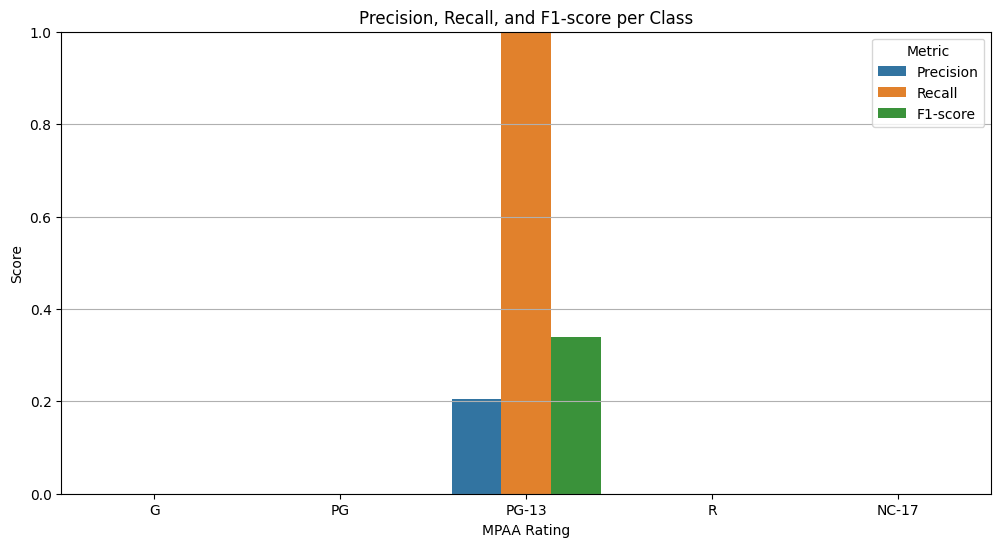

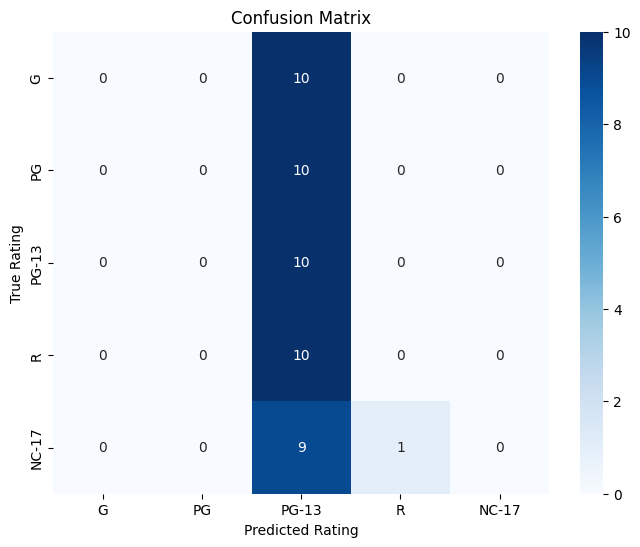


Scalar Metrics:
  MAE: 1.1800
  MSE: 1.9400
  Accuracy: 0.2000
  Linear Kappa: 0.0199
  Quadratic Kappa: 0.0396
  Spearman's Rho: 0.2020
  Cumulative Accuracy (Tol 0): 0.2000
  Cumulative Accuracy (Tol 1): 0.6200


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Extract metrics from the test results
metrics = test_results
precision = metrics['eval_precision']
recall = metrics['eval_recall']
f1 = metrics['eval_f1']
confusion_matrix_data = np.array(metrics['eval_confusion_matrix'])

# Get class labels from the corrected mapping
class_labels = list(rating_mapping.keys())

# 1. Visualize Precision, Recall, and F1-score per class
metrics_df = pd.DataFrame({
    'Metric': ['Precision'] * len(class_labels) + ['Recall'] * len(class_labels) + ['F1-score'] * len(class_labels),
    'Class': class_labels * 3,
    'Score': precision + recall + f1
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df)
plt.title('Precision, Recall, and F1-score per Class')
plt.ylabel('Score')
plt.xlabel('MPAA Rating')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# 2. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.show()

# You can also print other scalar metrics
print("\nScalar Metrics:")
print(f"  MAE: {metrics['eval_mae']:.4f}")
print(f"  MSE: {metrics['eval_mse']:.4f}")
print(f"  Accuracy: {metrics['eval_accuracy']:.4f}")
print(f"  Linear Kappa: {metrics['eval_linear_kappa']:.4f}")
print(f"  Quadratic Kappa: {metrics['eval_quadratic_kappa']:.4f}")
print(f"  Spearman's Rho: {metrics['eval_spearman_rho']:.4f}" if not np.isnan(metrics['eval_spearman_rho']) else f"  Spearman's Rho: NaN")
print(f"  Cumulative Accuracy (Tol 0): {metrics['eval_cumulative_accuracy_tol0']:.4f}")
print(f"  Cumulative Accuracy (Tol 1): {metrics['eval_cumulative_accuracy_tol1']:.4f}")


--- Classification Report ---
              precision    recall  f1-score   support

           G       0.00      0.00      0.00        10
          PG       0.00      0.00      0.00        10
       PG-13       0.20      1.00      0.34        10
           R       0.00      0.00      0.00        10
       NC-17       0.00      0.00      0.00        10

    accuracy                           0.20        50
   macro avg       0.04      0.20      0.07        50
weighted avg       0.04      0.20      0.07        50


--- Ordinal-specific Metrics ---
Mean Absolute Error (MAE): 1.1800
Quadratic Weighted Kappa (QWK): 0.0396
Spearman's rank correlation: 0.2020

--- Confusion Matrix ---
[[ 0  0 10  0  0]
 [ 0  0 10  0  0]
 [ 0  0 10  0  0]
 [ 0  0 10  0  0]
 [ 0  0  9  1  0]]


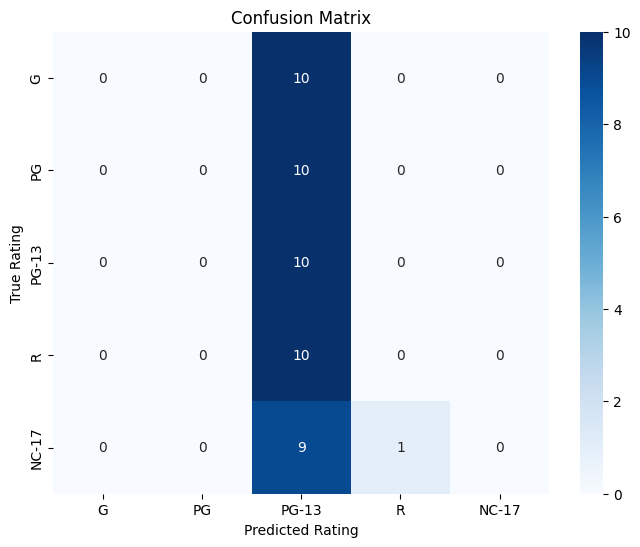


--- ROC and Precision-Recall Curves ---


/tmp/ipython-input-3324734019.py:147: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(class_labels))


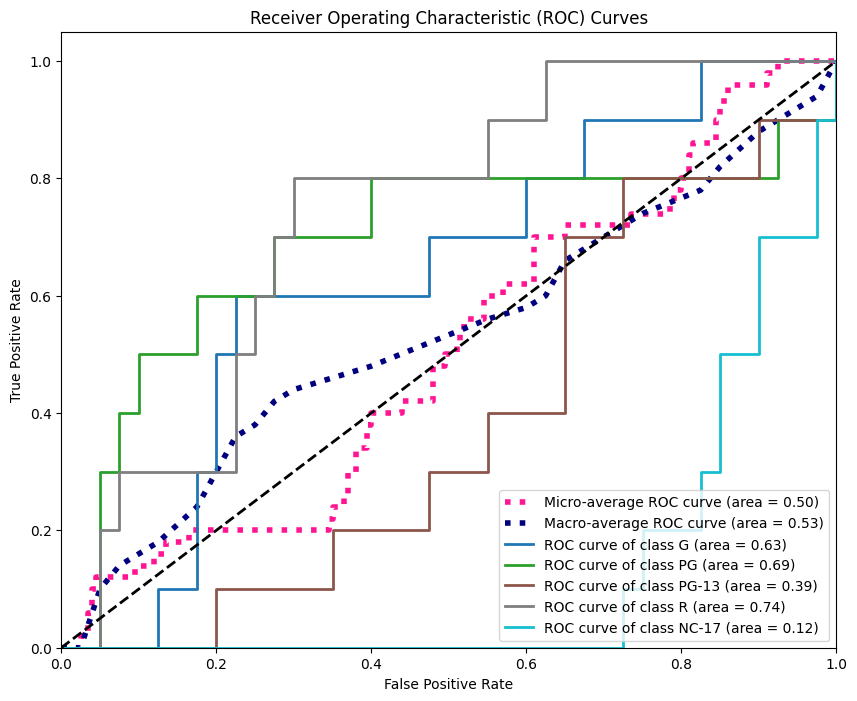

/tmp/ipython-input-3324734019.py:180: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(class_labels))


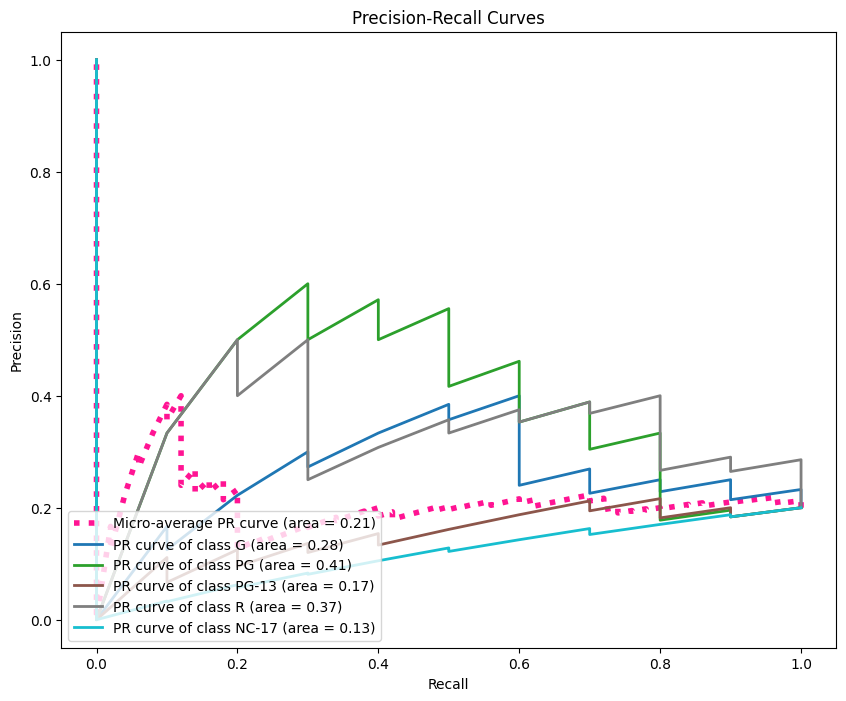


--- Saving Results ---
Results saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_Bert_ordinal_bal/bert_ordinal_evaluation_results.xlsx


In [11]:
from sklearn.metrics import classification_report, cohen_kappa_score, mean_absolute_error, roc_curve, auc, precision_recall_curve, confusion_matrix, average_precision_score
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import label_binarize
import joblib

# Ensure the output directory exists
output_dir = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_Bert_ordinal_bal/"
os.makedirs(output_dir, exist_ok=True)


# Make predictions on the test set
# The Trainer's predict method returns a TUPLE: (predictions, label_ids, metrics)
# predictions will be the raw cumulative logits in this case
predictions = trainer.predict(test_dataset)
cumulative_logits = predictions.predictions # Shape: (num_samples, num_labels - 1)
true_labels = predictions.label_ids        # Shape: (num_samples,)

# Convert cumulative logits to predicted class labels
# The predicted class is the number of thresholds passed (i.e., the number of positive logits)
predicted_classes = np.sum(cumulative_logits > 0, axis=1)

# Ensure predicted_classes have the same data type as true_labels for metrics calculation
predicted_classes = predicted_classes.astype(true_labels.dtype)

# Get class labels from the corrected mapping
class_labels = list(rating_mapping.keys()) # Use the rating_mapping defined earlier

# --- 1. Standard Classification Report ---
print("\n--- Classification Report ---")
report = classification_report(true_labels, predicted_classes, target_names=class_labels, zero_division=0, output_dict=True)
print(classification_report(true_labels, predicted_classes, target_names=class_labels, zero_division=0))

# Convert report to DataFrame for easier saving
report_df = pd.DataFrame(report).transpose()

# --- 2. Ordinal-specific Metrics ---
print("\n--- Ordinal-specific Metrics ---")
# Mean Absolute Error (MAE)
mae = mean_absolute_error(true_labels, predicted_classes)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(true_labels, predicted_classes, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")

# Spearman's rank correlation
spearman_rho, _ = spearmanr(true_labels, predicted_classes)
print(f"Spearman's rank correlation: {spearman_rho:.4f}" if not np.isnan(spearman_rho) else "Spearman's rank correlation: NaN")

# Calculate other scalar metrics that were in the Trainer output
accuracy = accuracy_score(true_labels, predicted_classes)
mse = mean_squared_error(true_labels, predicted_classes)
linear_kappa = cohen_kappa_score(true_labels, predicted_classes, weights='linear')
cumulative_accuracy_tol0 = np.mean(predicted_classes == true_labels)
cumulative_accuracy_tol1 = np.mean(np.abs(predicted_classes - true_labels) <= 1)


# Store all scalar metrics in a DataFrame
scalar_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'Accuracy', 'Linear Kappa', 'Quadratic Kappa', 'Spearman Rho', 'Cumulative Accuracy (Tol 0)', 'Cumulative Accuracy (Tol 1)'],
    'Score': [mae, mse, accuracy, linear_kappa, qwk, spearman_rho, cumulative_accuracy_tol0, cumulative_accuracy_tol1]
})


# --- 3. Confusion Matrix (as a heatmap) ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_labels, predicted_classes, labels=np.arange(len(class_labels)))
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
plt.show()


# --- 4. ROC and Precision-Recall Curves ---
print("\n--- ROC and Precision-Recall Curves ---")

# Binarize the true labels for one-vs-rest approach
true_labels_binarized = label_binarize(true_labels, classes=np.arange(len(class_labels)))

# Get predicted probabilities for each class
# For ordinal regression, we can get the probability of being in class k by:
# P(Y <= k) = sigmoid(logit_k)
# P(Y = k) = P(Y <= k) - P(Y <= k-1)
# P(Y = 0) = P(Y <= 0) = sigmoid(logit_0)
# P(Y = 1) = P(Y <= 1) - P(Y <= 0) = sigmoid(logit_1) - sigmoid(logit_0)
# ...
# P(Y = K-1) = 1 - P(Y <= K-2) = 1 - sigmoid(logit_K-2)

cumulative_probs = torch.sigmoid(torch.tensor(cumulative_logits)).numpy() # Convert logits to probabilities

# Calculate class probabilities
predicted_probs = np.zeros((cumulative_probs.shape[0], len(class_labels)))
predicted_probs[:, 0] = cumulative_probs[:, 0] # P(Y=0) = P(Y<=0)
for i in range(1, len(class_labels) - 1):
    predicted_probs[:, i] = cumulative_probs[:, i] - cumulative_probs[:, i-1] # P(Y=i) = P(Y<=i) - P(Y<=i-1)
predicted_probs[:, -1] = 1 - cumulative_probs[:, -2] # P(Y=K-1) = 1 - P(Y<=K-2)


# ROC Curve
plt.figure(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_labels))]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(class_labels)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it and compute AUC
mean_tpr /= len(class_labels)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC curve (area = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('tab10', len(class_labels))
for i, class_label in enumerate(class_labels):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of class {class_label} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.savefig(os.path.join(output_dir, 'roc_curves.png'))
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(10, 8))
precision = dict()
recall = dict()
average_precision = dict()
for i in range(len(class_labels)):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    average_precision[i] = average_precision_score(true_labels_binarized[:, i], predicted_probs[:, i])

# Compute micro-average Precision-Recall curve and area
precision["micro"], recall["micro"], _ = precision_recall_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
average_precision["micro"] = average_precision_score(true_labels_binarized, predicted_probs, average="micro")

# Plot all Precision-Recall curves
plt.plot(recall["micro"], precision["micro"],
         label=f'Micro-average PR curve (area = {average_precision["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('tab10', len(class_labels))
for i, class_label in enumerate(class_labels):
    plt.plot(recall[i], precision[i], color=colors(i), lw=2,
             label=f'PR curve of class {class_label} (area = {average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="lower left")
plt.savefig(os.path.join(output_dir, 'precision_recall_curves.png'))
plt.show()


# --- 5. Save Results to Excel File ---
print("\n--- Saving Results ---")

# Create a dictionary to hold all results
all_results = {
    'Classification Report': report_df,
    'Scalar Metrics': scalar_metrics_df, # Include the new scalar metrics DataFrame
    'Confusion Matrix': pd.DataFrame(cm, index=class_labels, columns=class_labels) # Save CM as DataFrame
}

# Save to Excel
excel_path = os.path.join(output_dir, 'bert_ordinal_evaluation_results.xlsx')
with pd.ExcelWriter(excel_path) as writer:
    for sheet_name, df_to_save in all_results.items():
        df_to_save.to_excel(writer, sheet_name=sheet_name)

print(f"Results saved to: {excel_path}")

In [12]:
import pandas as pd
import numpy as np
import torch

# Re-define ScriptDataset class as it's needed for evaluating on the validation set
class ScriptDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        # Each item is a dictionary containing the tokenized chunks and the label
        return {
            'tokenized_chunks': row['tokenized_chunks'],
            'labels': row['rating_encoded']
        }

# Assuming train_df, val_df, test_df, and rating_mapping are defined in previous cells
# If not, you would need to re-run those cells or include their code here.
# Based on the notebook state, train_df, val_df, test_df, and rating_mapping are available.

# Create datasets (re-creating them to ensure they are available in this cell's execution environment)
train_dataset = ScriptDataset(train_df)
val_dataset = ScriptDataset(val_df)
test_dataset = ScriptDataset(test_df)

# Extract metrics from test_results (which contains evaluation on the test set)
test_accuracy = test_results['eval_accuracy']
test_mae = test_results['eval_mae']
test_qwk = test_results['eval_quadratic_kappa']
test_spearman = test_results['eval_spearman_rho']
test_f1_scores = test_results['eval_f1']

# Extract metrics from the classification report (which was generated using the test set)
# The classification report dictionary contains macro avg and weighted avg
test_macro_f1 = report['macro avg']['f1-score']
test_weighted_f1 = report['weighted avg']['f1-score'] # Although not requested, often useful

# Get F1-scores per class for the test set from the classification report
test_f1_g = report['G']['f1-score']
test_f1_nc17 = report['NC-17']['f1-score']
test_f1_pg = report['PG']['f1-score']
test_f1_pg13 = report['PG-13']['f1-score']
test_f1_r = report['R']['f1-score']


# To get validation set metrics, we need to re-evaluate the model on the validation set
# The Trainer object is available, so we can use trainer.evaluate(val_dataset)
print("Evaluating on the validation set to get metrics...")
val_results = trainer.evaluate(val_dataset)
print("Validation set evaluation results:")
print(val_results)

# Extract metrics from val_results
val_accuracy = val_results['eval_accuracy']
val_mae = val_results['eval_mae']
val_qwk = val_results['eval_quadratic_kappa']
val_spearman = val_results['eval_spearman_rho']
val_f1_scores = val_results['eval_f1'] # This is a list of F1 scores per class from compute_metrics

# Calculate Macro F1 for validation set from the list of F1 scores per class
# Need to handle potential NaN values if a class has no true or predicted samples
val_macro_f1 = np.nanmean(val_f1_scores) # Use nanmean to ignore NaN values


# Get F1-scores per class for the validation set from the list of F1 scores
# Need to map the list indices to class labels
# Assuming the order in val_f1_scores is the same as in class_labels (G, PG, PG-13, R, NC-17)
val_f1_g = val_f1_scores[class_labels.index('G')]
val_f1_nc17 = val_f1_scores[class_labels.index('NC-17')]
val_f1_pg = val_f1_scores[class_labels.index('PG')]
val_f1_pg13 = val_f1_scores[class_labels.index('PG-13')]
val_f1_r = val_f1_scores[class_labels.index('R')]


# Create a DataFrame to display the requested metrics
metrics_summary = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Macro F1-Score', 'MAE', 'Quadratic Weighted Kappa', 'Spearman Correlation',
        'F1-Score (G)', 'F1-Score (NC-17)', 'F1-Score (PG)', 'F1-Score (PG-13)', 'F1-Score (R)'
    ],
    'Validation Set': [
        val_accuracy, val_macro_f1, val_mae, val_qwk, val_spearman,
        val_f1_g, val_f1_nc17, val_f1_pg, val_f1_pg13, val_f1_r
    ],
    'Test Set': [
        test_accuracy, test_macro_f1, test_mae, test_qwk, test_spearman,
        test_f1_g, test_f1_nc17, test_f1_pg, test_f1_pg13, test_f1_r
    ]
})

# Display the summary table
display(metrics_summary)

# --- Save Metrics Summary to Excel ---
output_dir = "/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_Bert_ordinal_bal/"
excel_path = os.path.join(output_dir, 'bert_ordinal_evaluation_results.xlsx')

# Use ExcelWriter in append mode ('a') to add a new sheet
with pd.ExcelWriter(excel_path, engine='openpyxl', mode='a') as writer:
    metrics_summary.to_excel(writer, sheet_name='Metrics Summary', index=False)

print(f"\nMetrics summary saved to: {excel_path}")

Evaluating on the validation set to get metrics...


Trainer is attempting to log a value of "[0.0, 0.0, 0.20833333333333334, 0.0, 0.0]" of type <class 'list'> for key "eval/precision" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[0.0, 0.0, 1.0, 0.0, 0.0]" of type <class 'list'> for key "eval/recall" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[0.0, 0.0, 0.3448275862068966, 0.0, 0.0]" of type <class 'list'> for key "eval/f1" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "[[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 8, 2, 0]]" of type <class 'list'> for key "eval/confusion_matrix" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


Validation set evaluation results:
{'eval_loss': 0.6076967716217041, 'eval_mae': 1.16, 'eval_mse': 1.88, 'eval_accuracy': 0.2, 'eval_linear_kappa': 0.039735099337748325, 'eval_quadratic_kappa': 0.07843137254901966, 'eval_spearman_rho': 0.2886751345948129, 'eval_cumulative_accuracy_tol0': 0.2, 'eval_cumulative_accuracy_tol1': 0.64, 'eval_precision': [0.0, 0.0, 0.20833333333333334, 0.0, 0.0], 'eval_recall': [0.0, 0.0, 1.0, 0.0, 0.0], 'eval_f1': [0.0, 0.0, 0.3448275862068966, 0.0, 0.0], 'eval_confusion_matrix': [[0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 10, 0, 0], [0, 0, 8, 2, 0]], 'eval_runtime': 1.8472, 'eval_samples_per_second': 27.068, 'eval_steps_per_second': 27.068, 'epoch': 3.0}


,Metric,Validation Set,Test Set
0,Accuracy,0.200000,0.200000
1,Macro F1-Score,0.068966,0.067797
2,MAE,1.160000,1.180000
3,Quadratic Weighted Kappa,0.078431,0.039604
4,Spearman Correlation,0.288675,0.202031
5,F1-Score (G),0.000000,0.000000
6,F1-Score (NC-17),0.000000,0.000000
7,F1-Score (PG),0.000000,0.000000
8,F1-Score (PG-13),0.344828,0.338983
9,F1-Score (R),0.000000,0.000000



Metrics summary saved to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/05_ConferencePaper_3/dataset/outputs/English_Bert_ordinal_bal/bert_ordinal_evaluation_results.xlsx
